# Netflix Movies & TV Shows Data Analysis using Python

## 1.Project Objective

The objective of this project is to analyze Netflix Movies and TV Shows data using Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn.

This project demonstrates:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- NumPy Statistical Operations
- Data Visualization
- Business Insights

### Libraries Used

- NumPy
- Pandas
- Matplotlib
- Seaborn

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">
2. Import Required Libraries
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")
sns.set_style("whitegrid")

# Default Figure Size
plt.rcParams["figure.figsize"]=(12,6)

# Netflix Theme Colors
NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#221F1F"
NETFLIX_GREY = "#6E6E6E"

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

3. Load Dataset</div>

In [2]:
df = pd.read_csv("netflix_titles.csv")
print("="*50)
print("NETFLIX MOVIES & TV SHOWS DATA ANALYSIS")
print("="*50)

print("\nDataset Loaded Successfully!\n")

print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
df.head()

NETFLIX MOVIES & TV SHOWS DATA ANALYSIS

Dataset Loaded Successfully!

Total Rows    : 8807
Total Columns : 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4. Data Cleaning</div>

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4.1 Missing Values Analysis</div>

In [3]:
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing = missing[missing["Missing Values"]>0]

missing

,Column,Missing Values
3,director,2634
4,cast,825
5,country,831
6,date_added,10
8,rating,4
9,duration,3


<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4.2 Duplicate Records</div>

In [4]:
print("Duplicate Records :",df.duplicated().sum())

Duplicate Records : 0


In [5]:
df.drop_duplicates(inplace=True)

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4.3 Date Formatting</div>

In [6]:
df["date_added"]=df["date_added"].str.strip()

In [7]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4.4 Feature Engineering</div>

In [8]:
df["Year Added"]=df["date_added"].dt.year

df["Month Added"]=df["date_added"].dt.month_name()

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

4.5 Extract Movie Duration</div>

In [ ]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.extract(r'(\d+)')

movies["duration"] = pd.to_numeric(movies["duration"])

In [ ]:
tv = df[df["type"] == "TV Show"].copy()

tv["duration"] = tv["duration"].str.extract(r'(\d+)')

tv["duration"] = pd.to_numeric(tv["duration"])

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

5. Statistical Analysis using NumPy</div>

In [11]:
duration=np.array(movies["duration"])

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

5.1 Movie Duration Statistics</div>

In [12]:
duration = movies["duration"].dropna().to_numpy()

In [13]:
print("="*40)
print("MOVIE DURATION STATISTICS")
print("="*40)

print(f"Average Duration      : {np.mean(duration):.2f} Minutes")
print(f"Median Duration       : {np.median(duration):.2f} Minutes")
print(f"Shortest Movie        : {np.min(duration):.0f} Minutes")
print(f"Longest Movie         : {np.max(duration):.0f} Minutes")
print(f"Standard Deviation    : {np.std(duration):.2f}")

MOVIE DURATION STATISTICS
Average Duration      : 99.58 Minutes
Median Duration       : 98.00 Minutes
Shortest Movie        : 3 Minutes
Longest Movie         : 312 Minutes
Standard Deviation    : 28.29


<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

5.2 Percentile Analysis</div>

In [14]:
print(f"25th Percentile : {np.percentile(duration,25):.0f} minutes")

print(f"75th Percentile : {np.percentile(duration,75):.0f} minutes")

25th Percentile : 87 minutes
75th Percentile : 114 minutes


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to identify meaningful patterns and trends within Netflix's content library. The following visualizations answer key business questions related to content type, countries, genres, ratings, release trends, and movie durations.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.1 Content Distribution on Netflix</div>

What proportion of Netflix's catalog consists of Movies and TV Shows?

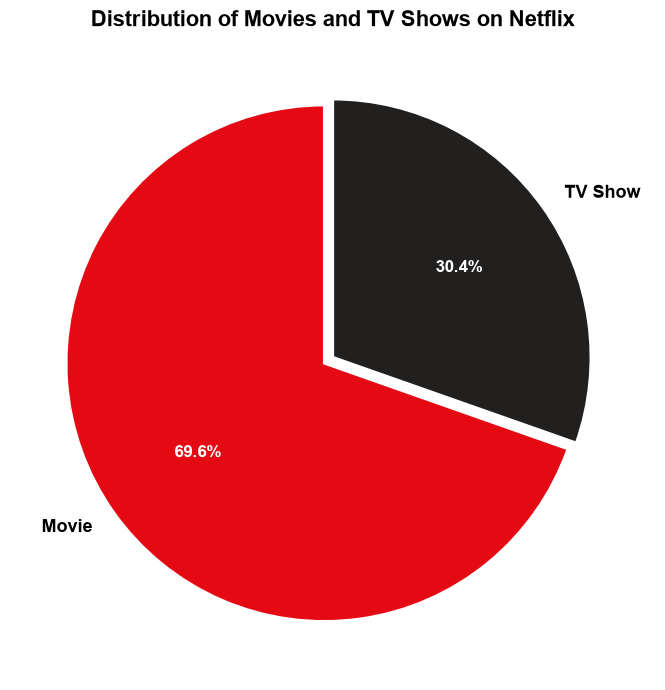

In [32]:
# Count Movies and TV Shows
content_type = df["type"].value_counts()

plt.figure(figsize=(7,7))

wedges, texts, autotexts =plt.pie(
    content_type,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[NETFLIX_RED, NETFLIX_BLACK],
    explode=(0.04,0),
    wedgeprops={"edgecolor":"white","linewidth":2},
    textprops={"fontsize":12}
)
for text in texts:
    text.set_color("black")
    text.set_fontsize(13)
    text.set_fontweight("bold")

# Make percentage values white
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

plt.title(
    "Distribution of Movies and TV Shows on Netflix",
    fontsize=16,
    fontweight="bold",
    color="black"
)

plt.tight_layout()
plt.show()

### Insight

- Movies constitute the majority of Netflix's content library.
- TV Shows represent a smaller but significant portion of the platform.
- Netflix appears to have invested more heavily in movie production and acquisition.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.2 Top 10 Countries Producing Netflix Content</div>

Which countries contribute the highest number of titles to Netflix?

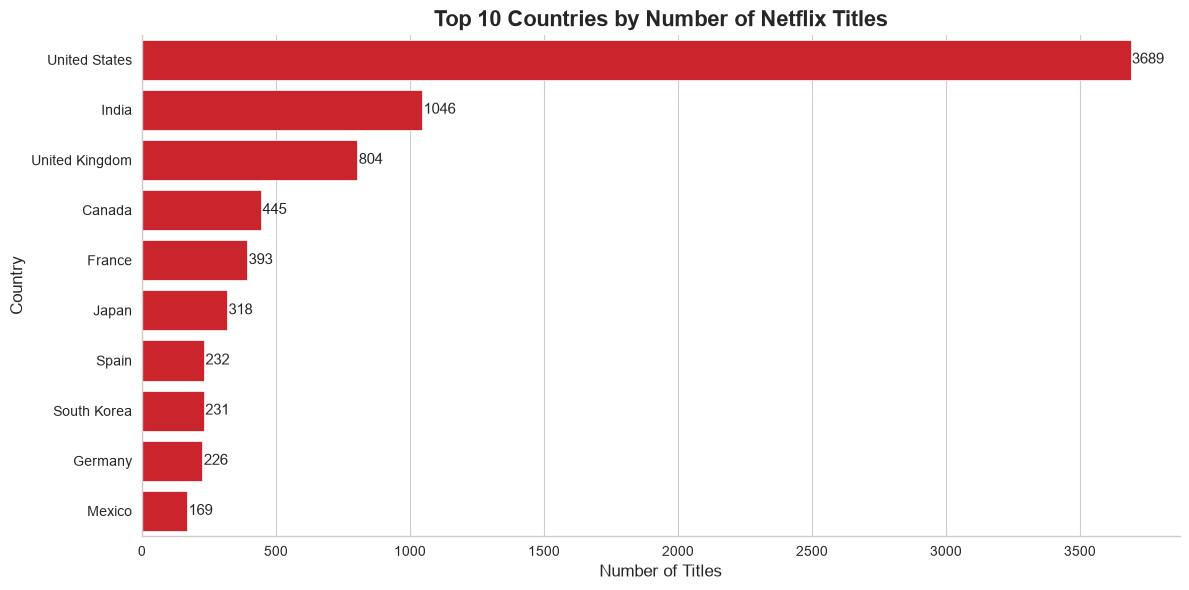

In [16]:
top_country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_country.values,
    y=top_country.index,
    color=NETFLIX_RED
)

# Value Labels
for i, value in enumerate(top_country.values):
    ax.text(value+5, i, str(value), va="center", fontsize=11)

plt.title(
    "Top 10 Countries by Number of Netflix Titles",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- The United States contributes the largest number of titles available on Netflix.
- India ranks among the top content-producing countries.
- Netflix has built a globally diverse content library with contributions from multiple regions.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.3 Genre Analysis</div>

Which genres dominate Netflix's content library?

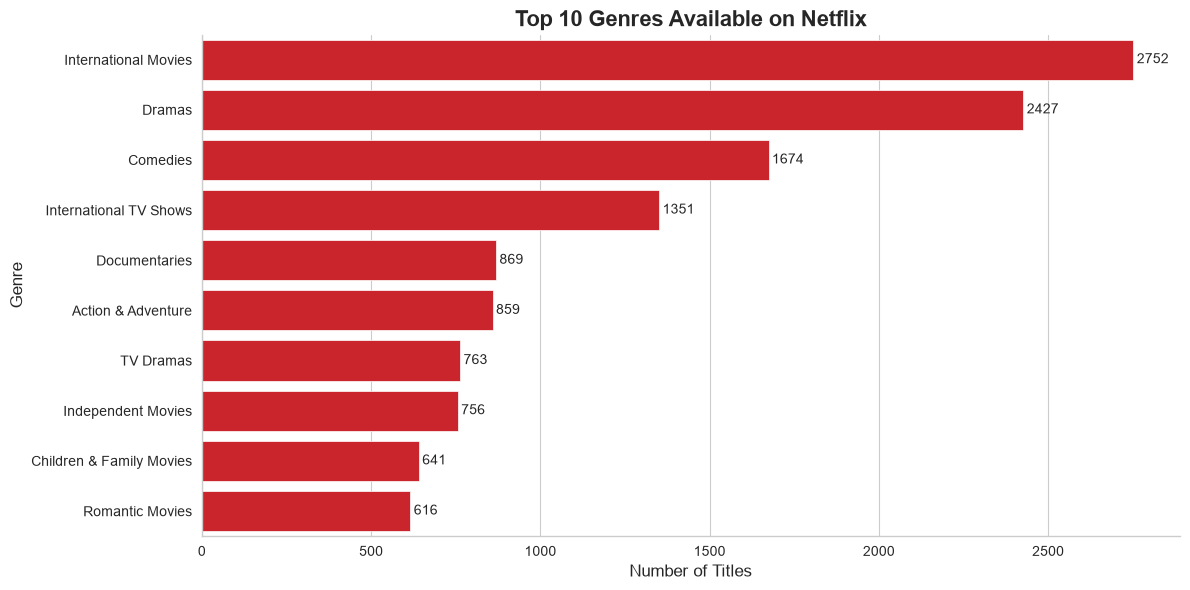

In [17]:
genre = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=genre.values,
    y=genre.index,
    color=NETFLIX_RED
)

for i, value in enumerate(genre.values):
    ax.text(value+10, i, str(value), va="center")

plt.title(
    "Top 10 Genres Available on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- International Movies and Dramas are among the most common genres.
- Netflix offers a wide variety of content to serve diverse audiences.
- Genre diversity reflects Netflix's global content strategy.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.4 Content Rating Analysis</div>

Which content ratings are most common on Netflix?

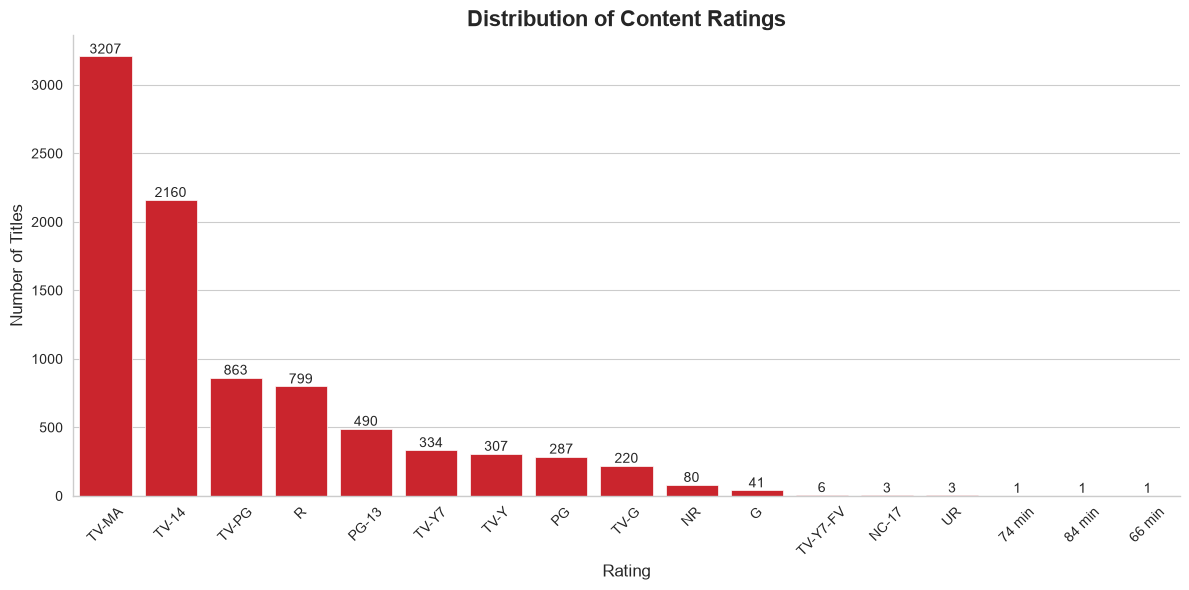

In [18]:
plt.figure(figsize=(12,6))

order = df["rating"].value_counts().index

ax = sns.countplot(
    data=df,
    x="rating",
    order=order,
    color=NETFLIX_RED
)

# Value Labels
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)

plt.title(
    "Distribution of Content Ratings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Rating")
plt.ylabel("Number of Titles")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- TV-MA is the most frequently assigned rating.
- A large proportion of Netflix's content is intended for mature audiences.
- Family-oriented content is also available but in comparatively smaller quantities.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.5 Netflix Content Growth Over Time</div>

How has Netflix expanded its content library over the years?

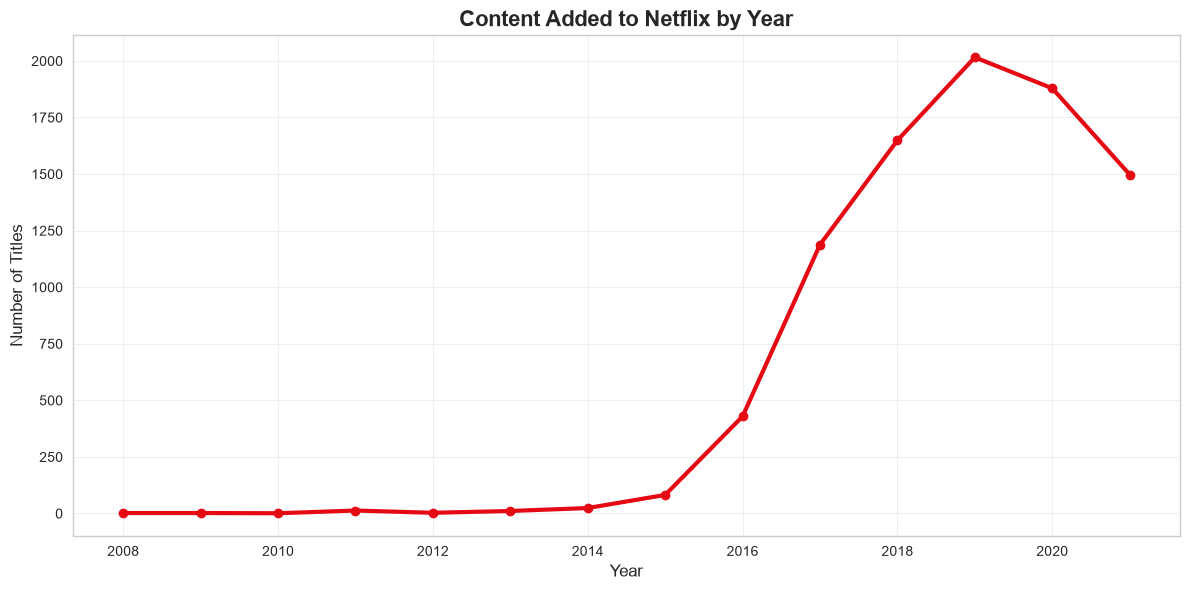

In [19]:
content_year = (
    df["Year Added"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    content_year.index,
    content_year.values,
    color=NETFLIX_RED,
    marker="o",
    linewidth=3
)

plt.title(
    "Content Added to Netflix by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.9 Movie Duration Distribution</div>

What is the distribution of movie durations?

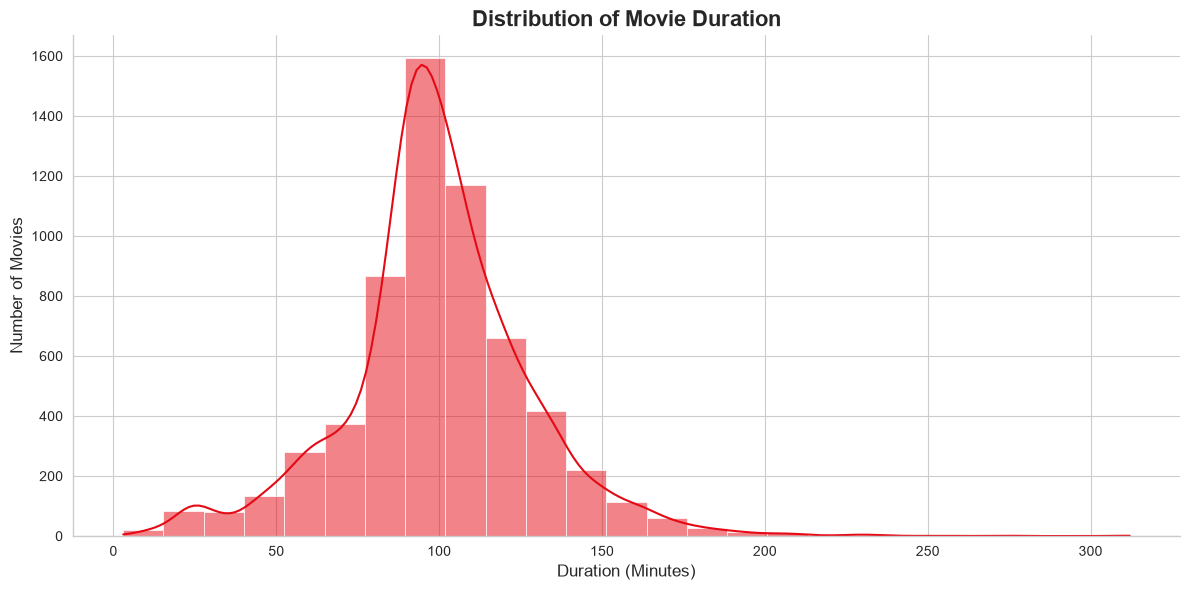

In [22]:
plt.figure(figsize=(12,6))

sns.histplot(
    movies["duration"],
    bins=25,
    kde=True,
    color=NETFLIX_RED
)

plt.title(
    "Distribution of Movie Duration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- Most Netflix movies have durations between 80 and 120 minutes.
- Extremely short and very long movies are comparatively rare.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.10 Top Directors</div>

Which directors have contributed the highest number of titles?

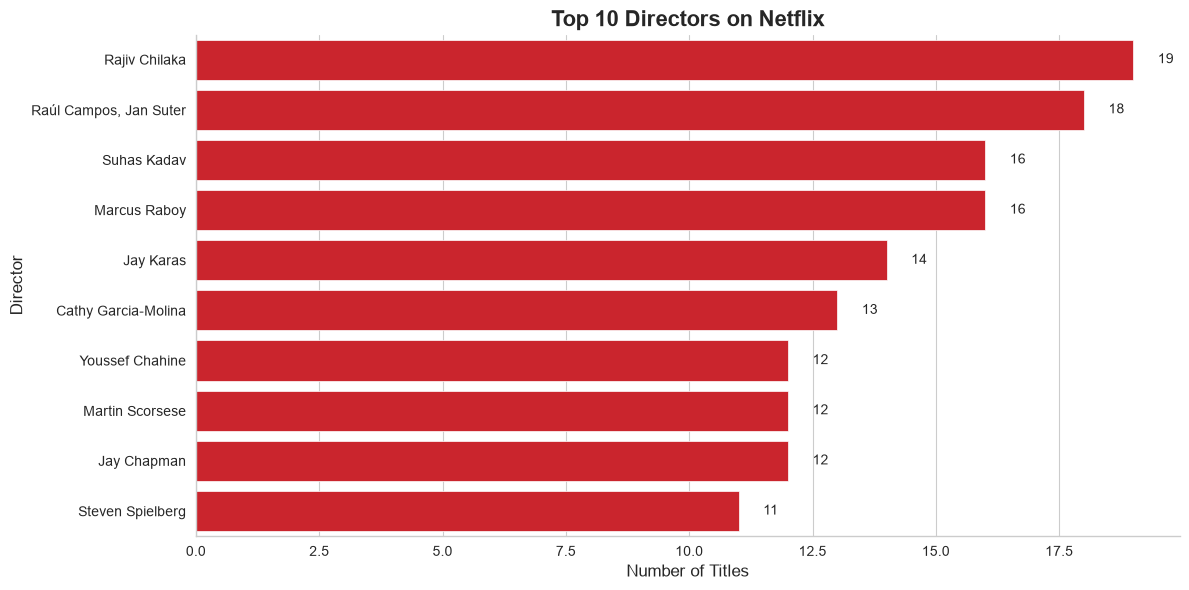

In [23]:
top_directors = (
    df["director"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    color=NETFLIX_RED
)

for i, value in enumerate(top_directors.values):
    ax.text(value+0.5, i, str(value), va="center")

plt.title(
    "Top 10 Directors on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Director")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- Some directors have collaborated with Netflix on multiple projects.
- Frequent collaborations may indicate successful partnerships.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.11 Top Actors</div>

Which actors appear most frequently in Netflix titles?

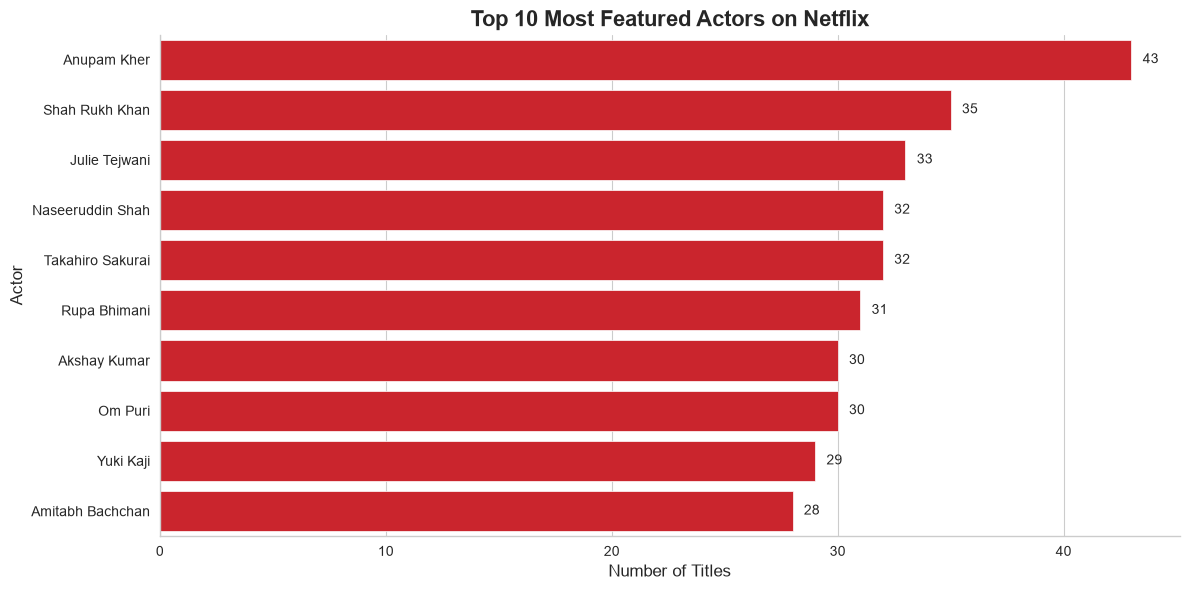

In [24]:
top_cast = (
    df["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_cast.values,
    y=top_cast.index,
    color=NETFLIX_RED
)

for i, value in enumerate(top_cast.values):
    ax.text(value+0.5, i, str(value), va="center")

plt.title(
    "Top 10 Most Featured Actors on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Actor")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- A few actors appear repeatedly across Netflix's catalog.
- These actors have a strong presence across multiple productions.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.12 Release Year Distribution</div>

Which release years dominate Netflix's content library?

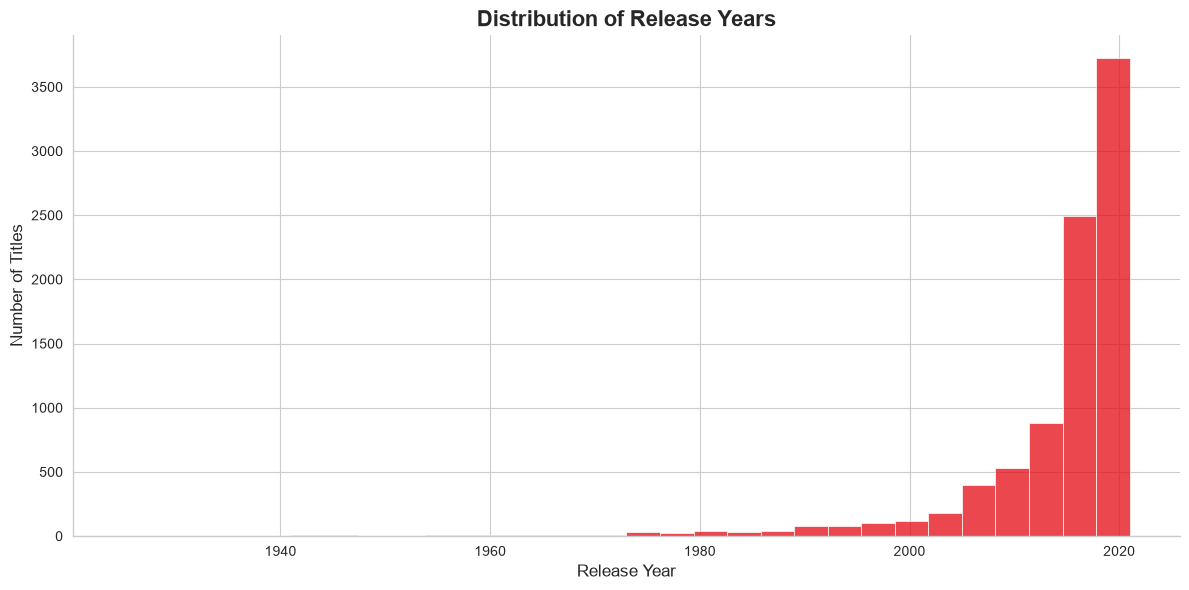

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["release_year"],
    bins=30,
    color=NETFLIX_RED
)

plt.title(
    "Distribution of Release Years",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- Most titles available on Netflix are relatively recent.
- Older content represents a smaller portion of the catalog.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.13 Relationship Between Release Year and Movie Duration</div>

Is there any relationship between release year and movie duration?

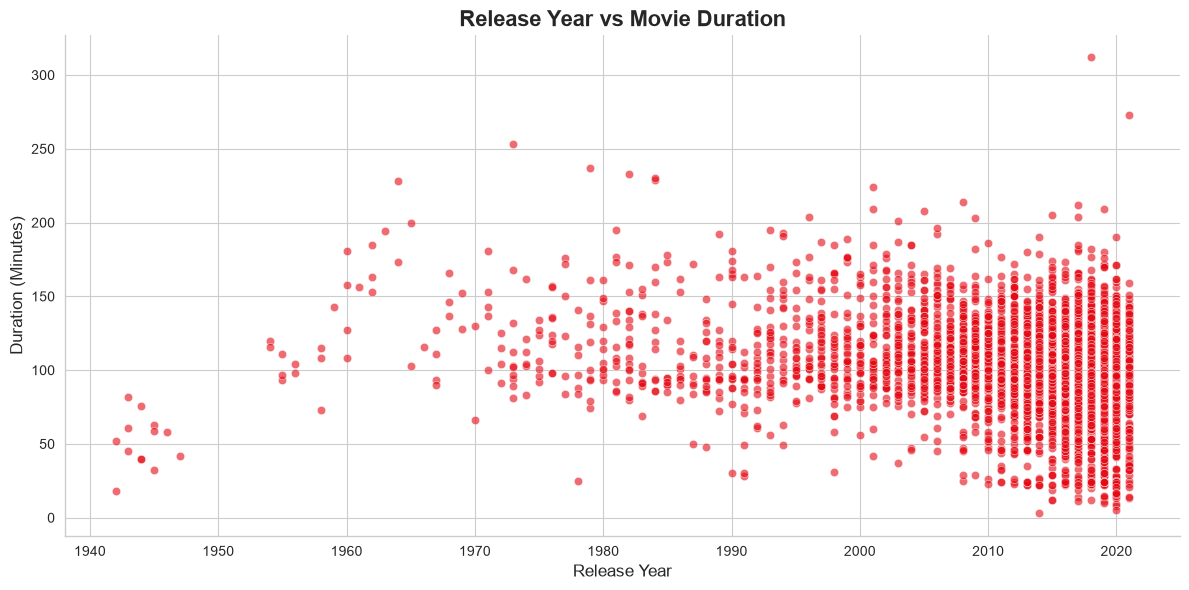

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=movies,
    x="release_year",
    y="duration",
    color=NETFLIX_RED,
    alpha=0.6
)

plt.title(
    
    "Release Year vs Movie Duration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

sns.despine()

plt.tight_layout()
plt.show()

### Insight

- Movie durations remain relatively consistent across different release years.
- No strong relationship is observed between release year and duration.

<div style="background-color: #E50914; color: white; padding: 8px; border-radius: 4px;">

6.14 Correlation Heatmap</div>

Is there a correlation between the available numerical features?

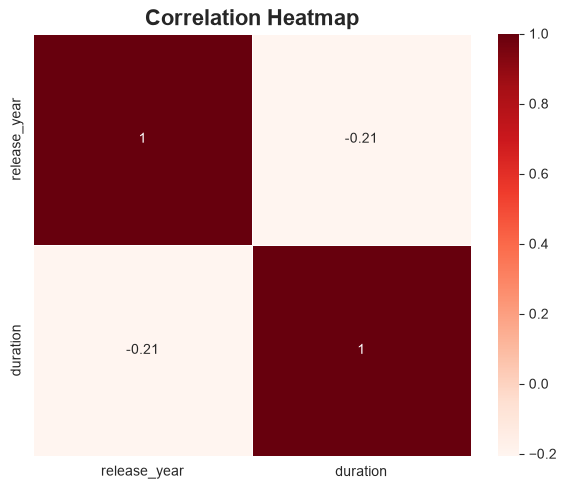

In [27]:
numeric_df = movies[["release_year","duration"]]

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Reds",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Insight

- The correlation between release year and movie duration is weak.
- This suggests that movie length has remained fairly stable over time.